## Engineering Assignment 3: Chemical Reactor Analysis
Brian Capellan-Santos  
Spring 2026

## Introduction

Modern chemical manufacturing rarely relies on a single reactor operating at fixed conditions. Instead, engineers design reactor networks and optimize operating temperatures to achieve high conversion, reduce energy consumption, and maintain product quality. Reactor configuration and temperature selection are among the most critical decisions in process design because reaction rate depends exponentially on temperature through the Arrhenius equation.

The purpose of this analysis is to evaluate how reactor arrangement (single reactor versus multiple reactors in series) and operating temperature influence overall conversion performance. Using kinetic modeling, vectorized numerical analysis with NumPy, and visualization with Matplotlib, this report compares reactor configurations and identifies optimal temperature conditions that satisfy target conversion requirements while minimizing energy demand.

Three engineering scenarios are investigated: temperature optimization for polymer production, comparison of CSTR reactors in series, and multi-temperature staged reactor operation. The results provide insight into how reactor networks enhance conversion efficiency and how temperature sensitivity impacts industrial reactor design decisions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

R = 8.314  # J/(mol·K)

In [2]:
def calculate_series_conversion(conversions):
    """
    Calculates overall conversion for reactors in series.

    Parameters:
        conversions (list or np.array): Individual reactor conversions

    Returns:
        float: Overall conversion
    """
    unreacted_fraction = np.prod(1 - np.array(conversions))
    overall_conversion = 1 - unreacted_fraction
    return overall_conversion

In [3]:
def calculate_temperature_profile(T_array, A, Ea, time):
    """
    Calculates rate constants and conversions over a temperature array.

    Returns:
        k_array, X_array
    """
    k_array = A * np.exp(-Ea / (R * T_array))
    X_array = 1 - np.exp(-k_array * time)
    return k_array, X_array

In [4]:
def find_optimal_temperature(T_min, T_max, A, Ea, time, target_conversion):
    """
    Finds lowest temperature that achieves target conversion.
    """
    T_array = np.linspace(T_min, T_max, 1000)
    k_array = A * np.exp(-Ea / (R * T_array))
    X_array = 1 - np.exp(-k_array * time)

    indices = np.where(X_array >= target_conversion)[0]

    if len(indices) == 0:
        return None

    idx = indices[0]

    return {
        'optimal_T': T_array[idx],
        'optimal_k': k_array[idx],
        'optimal_X': X_array[idx],
        'margin': X_array[idx] - target_conversion
    }

In [5]:
def compare_reactor_configurations(config_specs):
    """
    Compares 1, 2, and 3 CSTRs in series.
    """

    A = config_specs['A']
    Ea = config_specs['Ea']
    T = config_specs['temperature']
    total_time = config_specs['total_available_time']
    target = config_specs['target_conversion']

    k = A * np.exp(-Ea / (R * T))

    results = {}

    for n in [1, 2, 3]:

        tau = total_time / n

        individual_X = (k * tau) / (1 + k * tau)

        conversions = [individual_X] * n
        overall_X = calculate_series_conversion(conversions)

        results[f'{n}_reactor'] = {
            'individual_conversion': individual_X,
            'overall_conversion': overall_X,
            'meets_target': overall_X >= target,
            'time_per_reactor': tau
        }

    return results

## Scenario 1

In [7]:
A1 = 3.5e6
Ea1 = 68000
time1 = 5400
target1 = 0.90

T_array = np.linspace(320, 380, 100)
k_array, X_array = calculate_temperature_profile(T_array, A1, Ea1, time1)

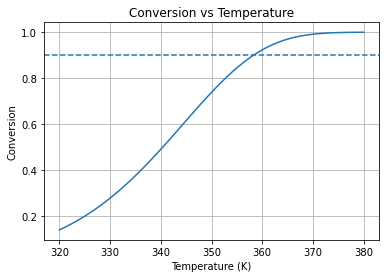

In [8]:
plt.figure()
plt.plot(T_array, X_array)
plt.axhline(target1, linestyle='--')
plt.xlabel("Temperature (K)")
plt.ylabel("Conversion")
plt.title("Conversion vs Temperature")
plt.grid()
plt.show()

In [9]:
optimal_results = find_optimal_temperature(320, 380, A1, Ea1, time1, target1)
optimal_results

{'optimal_T': 358.31831831831835,
 'optimal_k': 0.0004274257068933264,
 'optimal_X': 0.9005498551551272,
 'margin': 0.0005498551551271769}

In [11]:
k_current = A1 * np.exp(-Ea1 / (R * 360))
X_current = 1 - np.exp(-k_current * time1)

## Scenario 2

In [12]:
scenario2 = {
    'A': 1.2e8,
    'Ea': 75000,
    'temperature': 350,
    'total_available_time': 7200,
    'target_conversion': 0.95
}

results2 = compare_reactor_configurations(scenario2)
results2

{'1_reactor': {'individual_conversion': 0.8469344477105106,
  'overall_conversion': 0.8469344477105106,
  'meets_target': False,
  'time_per_reactor': 7200.0},
 '2_reactor': {'individual_conversion': 0.7345067641894818,
  'overall_conversion': 0.9295133417388606,
  'meets_target': False,
  'time_per_reactor': 3600.0},
 '3_reactor': {'individual_conversion': 0.648429889420261,
  'overall_conversion': 0.9565453919816409,
  'meets_target': True,
  'time_per_reactor': 2400.0}}

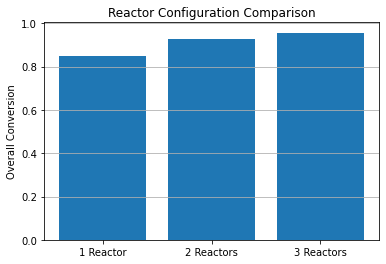

In [13]:
labels = ['1 Reactor', '2 Reactors', '3 Reactors']
conversions = [
    results2['1_reactor']['overall_conversion'],
    results2['2_reactor']['overall_conversion'],
    results2['3_reactor']['overall_conversion']
]

plt.figure()
plt.bar(labels, conversions)
plt.ylabel("Overall Conversion")
plt.title("Reactor Configuration Comparison")
plt.grid(axis='y')
plt.show()

## Scenario 3

In [14]:
A3 = 1.5e8
Ea3 = 80000
tau3 = 1800

temps = [340, 360, 380]

stage_conversions = []

for T in temps:
    k = A3 * np.exp(-Ea3 / (R * T))
    X = 1 - np.exp(-k * tau3)
    stage_conversions.append(X)

stage_conversions

[0.1290500968785132, 0.48606128130080384, 0.9339730474857634]

In [15]:
cumulative = []
for i in range(1, 4):
    cumulative.append(
        calculate_series_conversion(stage_conversions[:i])
    )

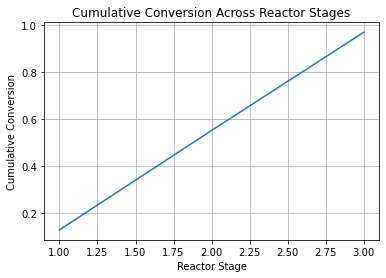

In [16]:
plt.figure()
plt.plot([1,2,3], cumulative)
plt.xlabel("Reactor Stage")
plt.ylabel("Cumulative Conversion")
plt.title("Cumulative Conversion Across Reactor Stages")
plt.grid()
plt.show()

## Conclusion

This study demonstrates how reactor configuration and temperature strongly influence chemical reactor performance. Temperature optimization significantly reduces energy costs while maintaining target conversion. Series reactor configurations improve overall conversion efficiency compared to a single reactor with equivalent total residence time. Multi-temperature staging enables controlled conversion increases while managing reaction rates at each stage. These results highlight the importance of kinetic analysis and reactor network design in optimizing industrial chemical processes.

### Question 1

Energy cost is proportional to: Energy ~ (T - 293)
where 293 K is ambient temperature.

Energy at current temperature: E_current = 360 - 293
Energy at optimal temperature: E_opt = T_opt - 293

Percent energy savings: percent_savings = ((E_current - E_opt) / E_current) * 100

Which expands to
percent_savings = ((360 - 293) - (T_opt - 293)) / (360 - 293) * 100

Higher temperatures require more heating energy, so reducing the operating temperature while still achieving the target conversion results in energy savings.

### Question 2
Single reactor conversion: X = (k * tau) / (1 + k * tau)

Two reactors in series: X_overall = 1 - (1 - X)^2

Three reactors in series: X_overall = 1 - (1 - X)^3

Each reactor removes some fraction of the remaining reactant. The unreacted portion leaving one reactor becomes the feed to the next reactor, so the remaining fraction multiplies. This causes the overall unreacted fraction (1 - X) to shrink exponentially, increasing total conversion.

### Question 3

X1 = conversion in reactor 1
X2 = conversion in reactor 2
X3 = conversion in reactor 3

After R1:
X_total1 = X1

After R1 + R2:
X_total2 = 1 - (1 - X1)*(1 - X2)

After R1 + R2 + R3:
X_total3 = 1 - (1 - X1)*(1 - X2)*(1 - X3)

Contribution from each stage:
Stage 1 gain = X_total1
Stage 2 gain = X_total2 - X_total1
Stage 3 gain = X_total3 - X_total2

Later reactors add less conversion because less reactant remains, so each stage experiences diminishing returns.

### Question 4

Evaluate conversion at:
T_low  = T_opt - 5
T_high = T_opt + 5

Rate constant formula: k = A * exp(-Ea / (R * T))

Conversion formula: X = 1 - exp(-k * time)

conversion_range = [X_low , X_high

Check Is X_low >= 0.90 ?

If yes, the process has a sufficient safety margin.

## Question 5

k = A * exp(-Ea / (R * T))

If Ea is smaller: exp(-Ea / (R*T))

changes less when T changes.

This means 
Reaction becomes less temperature sensitive. Rate constant changes more slowly with temperature. Conversion differences between reactor configurations shrink

With lower activation energy, the reaction rate becomes less dependent on temperature. This reduces the advantage gained by staging reactors or optimizing temperature, since the reaction proceeds at similar rates across different conditions.